# Example 7: Benchmark ISOSIMpy against TracerLPM
In this example, we benchmark simulation results from ISOSIMpy against equivalent results obtained from TracerLPM. We consider the tracer input data given in Example 3 of the TracerLPM documentation [(Jurgens et al., 2012)](https://pubs.usgs.gov/publication/tm4F3). We generated simulation results using different model units in TracerLPM and compare those results against those obtained with ISOSIMpy.

In [1]:
import ISOSIMpy.model as ism
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

## 1. Load Tracer Input Signal

In [2]:
# load input series
# this would be the tracer concentration in precipitation or recharge in a
# practical problem
file_name = "TracerLPM_benchmark_input_yearly.csv"
data = np.genfromtxt(
    file_name,
    delimiter=",",
    dtype=["<U7", float],
    encoding="utf-8",
    skip_header=1
)

timestamps = np.array([datetime.strptime(row[0], r"%Y") for row in data])
input_series = np.array([row[1] for row in data], dtype=float)

In [3]:
# load benchmark data
file_name = "TracerLPM_benchmark_simulations.csv"
data = np.genfromtxt(
    file_name,
    delimiter=",",
    dtype=["<U7", float, float, float, float],
    encoding="utf-8",
    skip_header=1
)

timestamps_benchmark = np.array([datetime.strptime(row[0], r"%Y") for row in data])
data_benchmark = np.array([[row[1], row[2], row[3], row[4]] for row in data], dtype=float)

In [4]:
### define model (the true system; in practice we don't know this)
# get decay constant
# we assume a half life of 12.3 years
t_half = 12.3
lambda_ = np.log(2.0) / t_half

# create true observations using the model
# time step is 1 month
m = ism.Model(
    dt=1.0,
    lambda_=lambda_,
    input_series=input_series,
    steady_state_input=6.,
    n_warmup_half_lives=10
)

# add an piston-flow unit
# define the true model parameters
pm_mtt_true = 15. # 15 years
m.add_unit(
    ism.PMUnit(mtt=pm_mtt_true),
    fraction=1., # 100 percent of the overall response
    prefix="pm"
)

# simulate
pm_sim = m.simulate()

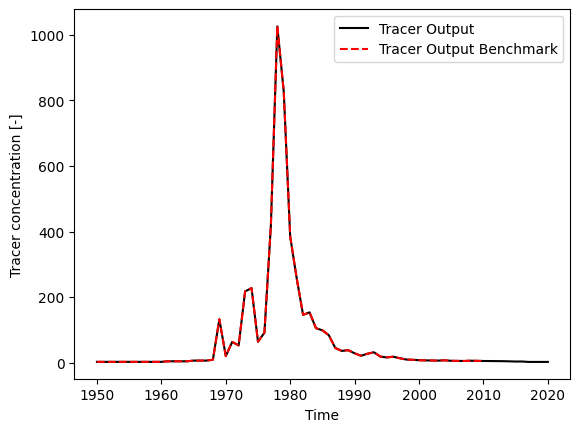

In [5]:
fig, ax = plt.subplots(1, 1)
start = 100
# ax.plot(
#     timestamps[start:],
#     input_series[start:],
#     label="Tracer Input",
#     c="grey"
# )
ax.plot(
    timestamps[start:],
    pm_sim[start:],
    label="Tracer Output",
    c="black"
)
ax.plot(
    timestamps_benchmark,
    data_benchmark[:, 0],
    label="Tracer Output Benchmark",
    c="red",
    ls="--"
)

ax.set_xlabel("Time")
ax.set_ylabel("Tracer concentration [-]")
ax.legend()
plt.show()

In [6]:
### define model (the true system; in practice we don't know this)
# get decay constant
# we assume a half life of 12.3 years
t_half = 12.3
lambda_ = np.log(2.0) / t_half

# create true observations using the model
# time step is 1 month
m = ism.Model(
    dt=1.0,
    lambda_=lambda_,
    input_series=input_series,
    steady_state_input=6.,
    n_warmup_half_lives=10
)

# add an piston-flow unit
# define the true model parameters
em_mtt_true = 15. # 15 years
m.add_unit(
    ism.EMUnit(mtt=em_mtt_true),
    fraction=1., # 100 percent of the overall response
    prefix="em"
)

# simulate
em_sim = m.simulate()

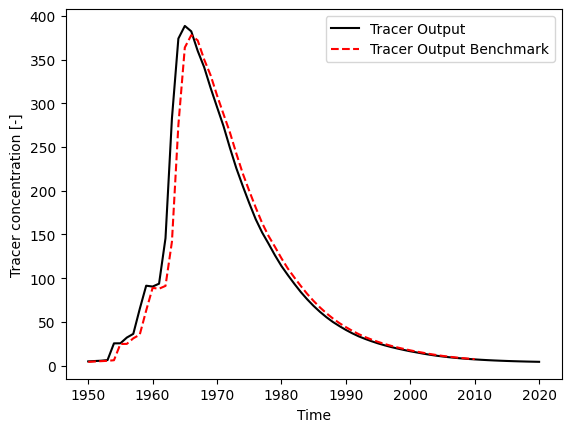

In [7]:
fig, ax = plt.subplots(1, 1)
start = 100
# ax.plot(
#     timestamps[start:],
#     input_series[start:],
#     label="Tracer Input",
#     c="grey"
# )
ax.plot(
    timestamps[start:],
    em_sim[start:],
    label="Tracer Output",
    c="black"
)
ax.plot(
    timestamps_benchmark,
    data_benchmark[:, 1],
    label="Tracer Output Benchmark",
    c="red",
    ls="--"
)

ax.set_xlabel("Time")
ax.set_ylabel("Tracer concentration [-]")
ax.legend()
plt.show()

In [8]:
### define model (the true system; in practice we don't know this)
# get decay constant
# we assume a half life of 12.3 years
t_half = 12.3
lambda_ = np.log(2.0) / t_half

# create true observations using the model
# time step is 1 month
m = ism.Model(
    dt=1.0,
    lambda_=lambda_,
    input_series=input_series,
    steady_state_input=6.,
    n_warmup_half_lives=10
)

# add an piston-flow unit
# define the true model parameters
epm_mtt_true = 15. # 15 years
epm_eta_true = 0.5 + 1. # eta = epm_ratio + 1
m.add_unit(
    ism.EPMUnit(mtt=em_mtt_true, eta=epm_eta_true),
    fraction=1., # 100 percent of the overall response
    prefix="epm"
)

# simulate
epm_sim = m.simulate()

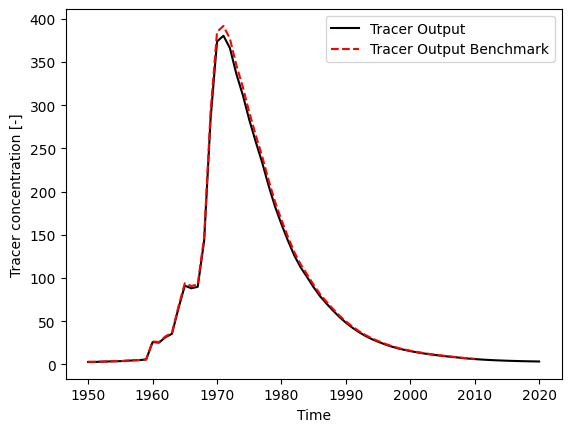

In [9]:
fig, ax = plt.subplots(1, 1)
start = 100
# ax.plot(
#     timestamps[start:],
#     input_series[start:],
#     label="Tracer Input",
#     c="grey"
# )
ax.plot(
    timestamps[start:],
    epm_sim[start:],
    label="Tracer Output",
    c="black"
)
ax.plot(
    timestamps_benchmark,
    data_benchmark[:, 2],
    label="Tracer Output Benchmark",
    c="red",
    ls="--"
)

ax.set_xlabel("Time")
ax.set_ylabel("Tracer concentration [-]")
ax.legend()
plt.show()

In [10]:
### define model (the true system; in practice we don't know this)
# get decay constant
# we assume a half life of 12.3 years
t_half = 12.3
lambda_ = np.log(2.0) / t_half

# create true observations using the model
# time step is 1 month
m = ism.Model(
    dt=1.0,
    lambda_=lambda_,
    input_series=input_series,
    steady_state_input=6.,
    n_warmup_half_lives=10
)

# add an piston-flow unit
# define the true model parameters
dm_mtt_true = 15. # 15 years
dm_dp_true = 0.5
m.add_unit(
    ism.DMUnit(mtt=dm_mtt_true, DP=dm_dp_true),
    fraction=1., # 100 percent of the overall response
    prefix="dm"
)

# simulate
dm_sim = m.simulate()

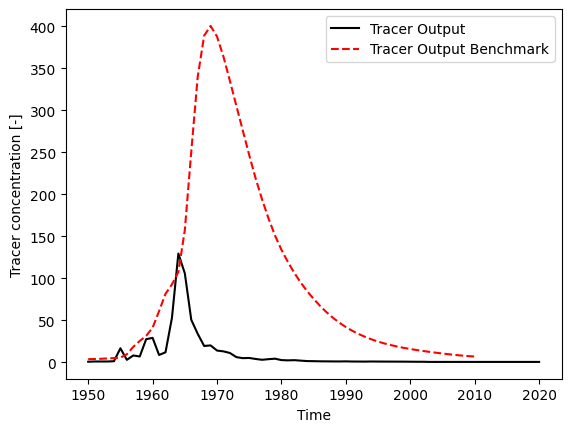

In [11]:
fig, ax = plt.subplots(1, 1)
start = 100
# ax.plot(
#     timestamps[start:],
#     input_series[start:],
#     label="Tracer Input",
#     c="grey"
# )
ax.plot(
    timestamps[start:],
    dm_sim[start:],
    label="Tracer Output",
    c="black"
)
ax.plot(
    timestamps_benchmark,
    data_benchmark[:, 3],
    label="Tracer Output Benchmark",
    c="red",
    ls="--"
)

ax.set_xlabel("Time")
ax.set_ylabel("Tracer concentration [-]")
ax.legend()
plt.show()